# 10 — Local WCS Center Bootstrap (order 5, solve-field)

**Purpose:** Estimate the uncertainty on the WCS center north angle using local
solve-field bootstrap resampling with fifth-order SIP solves only.
This is the quantity **X** in the paper's WCS orientation error budget.

**Run from the `Python (spectrangle WSL)` kernel.**  
Does not use the online astrometry.net API.

Solve confirmed to use index **4117** (verified from `.match` INDEXID).
Scale bounds 70–95 arcsec/px are the primary constraint; restricting to
index 4117 via `--index` is available in Cell 4 as an optional test.

## Cell 1 — Environment check

In [1]:
import sys, shutil, warnings, time, csv, json, platform, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.table import Table

# --- resolve package root (spectrangle/) from notebooks/ ---
_pkg_root = str(Path('..').resolve())
if _pkg_root not in sys.path:
    sys.path.insert(0, _pkg_root)

from extractor import extract_stars, make_xylist
from extractor.platesolve import (
    solve_plate, wcs_summary, LocalSolveFieldError, _col_array
)
from extractor.wcsangle import angle_diff_deg, center_wcs_angle_metrics, WcsAngleMetrics

# --- user-editable paths ---
BACKEND_CFG = "/mnt/c/Users/bassd/.astrometry/backend.cfg"
INDEX_DIR   = Path("/mnt/c/Users/bassd/astrometry-data/4100/")
FITS_PATH   = sorted((Path('..') / 'data').glob('*.fit'))[0]

# -------------------------------------------------------------------
print(f"Python        : {sys.executable}")
print(f"Version       : {sys.version.split()[0]}")
print(f"CWD           : {Path('.').resolve()}")
print(f"Platform      : {platform.system()} {platform.release()}")
if platform.system() == "Windows":
    print("\n*** WARNING: Windows kernel — local solve-field will fail.")
    print("    Switch to the 'Python (spectrangle WSL)' Jupyter kernel.")

sf = shutil.which("solve-field")
print(f"\nsolve-field   : {sf or 'NOT FOUND — install astrometry.net in WSL'}")
print(f"backend cfg   : {BACKEND_CFG}")
print(f"  exists      : {Path(BACKEND_CFG).exists()}")
print(f"index dir     : {INDEX_DIR}")
print(f"  exists      : {INDEX_DIR.exists()}")
if INDEX_DIR.exists():
    idx_files = sorted(INDEX_DIR.glob("index-41*.fits"))
    for p in idx_files:
        print(f"  {p.name}")

import extractor
print(f"\nextractor     : {extractor.__version__}  ({extractor.__file__})")

# matplotlib dark theme
plt.rcParams.update({
    'figure.facecolor': '#111', 'axes.facecolor': '#111',
    'text.color': 'white',      'axes.labelcolor': 'white',
    'xtick.color': '#ccc',      'ytick.color': '#ccc',
    'axes.edgecolor': '#555',   'axes.titlecolor': 'white',
    'legend.facecolor': '#1e1e1e', 'legend.edgecolor': '#555',
    'grid.color': '#333',       'grid.alpha': 0.4,
    'font.size': 10,            'axes.titlesize': 11,
    'savefig.facecolor': '#111','savefig.dpi': 150,
})

Python        : /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/bin/python
Version       : 3.11.0rc1
CWD           : /mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/notebooks
Platform      : Linux 5.15.167.4-microsoft-standard-WSL2

solve-field   : /usr/bin/solve-field
backend cfg   : /mnt/c/Users/bassd/.astrometry/backend.cfg
  exists      : True
index dir     : /mnt/c/Users/bassd/astrometry-data/4100
  exists      : True
  index-4115.fits
  index-4116.fits
  index-4117.fits
  index-4118.fits
  index-4119.fits

extractor     : 0.2.0  (/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/extractor/__init__.py)


## Cell 2 — Load image and detect sources

In [2]:
OUT_DIR = Path('..') / 'out' / 'local_bootstrap_10'
OUT_DIR.mkdir(parents=True, exist_ok=True)

with fits.open(FITS_PATH) as hdul:
    image       = hdul[0].data.astype(np.float32)
    orig_header = hdul[0].header.copy()

ny, nx = image.shape
print(f"Image  : {FITS_PATH.name}  ({nx} x {ny} px)")

# background-subtracted display image (shared across cells)
_bg   = gaussian_filter(image, sigma=50)
_proc = np.clip(image - _bg, 0, None)
_lo, _hi = np.percentile(_proc[np.isfinite(_proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(_proc, _lo, _hi))
_dlo, _dhi = float(np.arcsinh(_lo)), float(np.arcsinh(_hi))

# --- source extraction (cached to skip re-detection on re-runs) ---
_src_cache = OUT_DIR / 'sources.pkl'
if _src_cache.exists():
    with open(_src_cache, 'rb') as fh:
        all_xs, all_ys, all_fluxes = pickle.load(fh)
    print(f"Loaded {len(all_xs)} sources from cache.")
else:
    all_xs, all_ys, all_fluxes = extract_stars(
        image, max_sources=300, mask_spectra=True
    )
    with open(_src_cache, 'wb') as fh:
        pickle.dump((all_xs, all_ys, all_fluxes), fh)
    print(f"Detected and cached {len(all_xs)} sources.")

# TODO: if an illuminated-region aperture mask is implemented in extractor,
#       apply it here before bootstrap to exclude edge-of-field sources.
selected_xs, selected_ys, selected_fluxes = all_xs, all_ys, all_fluxes
print(f"Selected sources for bootstrap: {len(selected_xs)}")

Image  : fuji6_asi178_100_15s.fit  (3096 x 2080 px)
Detected and cached 255 sources.
Selected sources for bootstrap: 255


## Cell 3 — Fiducial order-5 local solve

Run once with the full source list to establish the reference WCS and center north angle.

In [3]:
FID_DIR   = OUT_DIR / 'fiducial'
FID_CACHE = OUT_DIR / 'fiducial_result.pkl'

# --- shared solve parameters (reused in bootstrap) ---
BACKEND_CFG_STR = str(BACKEND_CFG)
SCALE_LOW       = 70.0
SCALE_HIGH      = 95.0
TWEAK_ORDER     = 5
SOLVE_TIMEOUT   = 120   # seconds; local solve-field is typically < 30 s

def _make_wcs(header):
    """Build WCS, suppressing harmless FITS date-fix warnings."""
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FITSFixedWarning)
        return WCS(header)

def _read_match_meta(output_dir):
    """Return dict with indexid/nmatch/logodds from solve-field .match file."""
    p = Path(output_dir) / 'xylist.match'
    if not p.exists():
        return {}
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            with fits.open(str(p)) as h:
                t = Table(h[1].data)
                return dict(
                    indexid=int(t['INDEXID'][0]),
                    nmatch=int(t['NMATCH'][0]),
                    logodds=float(t['LOGODDS'][0]),
                )
    except Exception:
        return {}

if FID_CACHE.exists():
    print("Loading fiducial from cache...")
    with open(FID_CACHE, 'rb') as fh:
        fid_result = pickle.load(fh)
else:
    print(f"Running fiducial solve  ({len(selected_xs)} sources, order {TWEAK_ORDER}) ...")
    _t0 = time.time()
    fid_result = solve_plate(
        xs=selected_xs, ys=selected_ys,
        image_width=nx, image_height=ny,
        original_header=orig_header,
        backend='local',
        backend_config=BACKEND_CFG_STR,
        scale_units='arcsecperpix',
        scale_low=SCALE_LOW,
        scale_high=SCALE_HIGH,
        tweak_order=TWEAK_ORDER,
        output_dir=FID_DIR,
        timeout=SOLVE_TIMEOUT,
        verbose=True,
    )
    print(f"Fiducial solve finished in {time.time()-_t0:.1f}s")
    if fid_result is None:
        raise RuntimeError("Fiducial solve failed — check solve-field output above.")
    with open(FID_CACHE, 'wb') as fh:
        pickle.dump(fid_result, fh)

# --- WCS metrics ---
fid_wcs     = _make_wcs(fid_result.header)
fid_metrics = center_wcs_angle_metrics(fid_wcs, image.shape, compute_east=True)

# --- plate scale and FOV from WCS ---
_scales_deg = proj_plane_pixel_scales(fid_wcs)
_ps_arcsec  = float(np.mean(np.abs(_scales_deg)) * 3600)
_fov_x_deg  = float(np.abs(_scales_deg[0]) * nx)
_fov_y_deg  = float(np.abs(_scales_deg[1]) * ny)

# --- match metadata (index used) ---
_mmeta = _read_match_meta(FID_DIR)

print()
print("=== Fiducial WCS ===")
print(f"  Sources submitted : {len(fid_result.detected_x)}")
print(f"  Sources matched   : {len(fid_result.matched_x)}")
print(f"  Index used (INDEXID): {_mmeta.get('indexid', 'n/a')}")
print(f"  Match logodds     : {_mmeta.get('logodds', 'n/a'):.2f}")
print(f"  Plate scale       : {_ps_arcsec:.2f} arcsec/px")
print(f"  FOV               : {_fov_x_deg:.2f}° × {_fov_y_deg:.2f}°")
print(f"  WCS file          : {FID_DIR/'xylist.wcs'}")
print()
print("  Center pixel      :", f"({fid_metrics.x_center:.1f}, {fid_metrics.y_center:.1f})")
print("  Center RA/Dec     :", f"{fid_metrics.ra_deg:.6f}°  /  {fid_metrics.dec_deg:.6f}°")
print("  θ_north (fiducial):", f"{fid_metrics.north_angle_deg:.5f}°  (CCW from +x)")
print("  θ_east            :", f"{fid_metrics.east_angle_deg:.5f}°")
print()
print(wcs_summary(fid_result.header))

Running fiducial solve  (255 sources, order 5) ...
Wrote 255 sources → ../out/local_bootstrap_10/fiducial/xylist.fits
Running: /usr/bin/solve-field ../out/local_bootstrap_10/fiducial/xylist.fits --width 3096 --height 2080 --scale-units arcsecperpix --scale-low 70.0 --scale-high 95.0 --tweak-order 5 --dir ../out/local_bootstrap_10/fiducial --backend-config /mnt/c/Users/bassd/.astrometry/backend.cfg --overwrite --no-plots
  Reading input file 1 of 1: "../out/local_bootstrap_10/fiducial/xylist.fits"...
  Solving...
  Reading file "../out/local_bootstrap_10/fiducial/xylist.axy"...
  Field 1 did not solve (index index-4119.fits, field objects 1-10).
  Field 1 did not solve (index index-4118.fits, field objects 1-10).
    log-odds ratio 60.2687 (1.49402e+26), 21 match, 0 conflict, 40 distractors, 179 index.
    RA,Dec = (113.419,30.4343), pixel scale 80.6262 arcsec/pix.
    Hit/miss:   Hit/miss: -----+-++--+++---++--------++++--++++-------------+----+++--+(best)-------++-------+---++----+---

## Cell 4 — Bootstrap configuration

Edit `N_BOOT`, `BOOT_FRAC`, `BOOT_OUT`, or `INDEX_RESTRICT` here.

**`INDEX_RESTRICT`**: optionally pass `--index <path>` to solve-field so only
index-4117 is tried.  This makes each bootstrap solve slightly faster and
more deterministic.  Set to `None` to let scale bounds alone constrain the
search (all five 4100-series indices will be tried in order).

In [4]:
# ---- bootstrap parameters (edit freely) ----
N_BOOT   = 250
BOOT_FRAC = 0.80
BOOT_OUT  = OUT_DIR / 'boot_solves'
BOOT_OUT.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUT_DIR / 'bootstrap_results.csv'

# Restrict to index-4117 only?
# Confirmed as the index used by the fiducial solve (INDEXID = 4117).
# Set to None to search all available indices (scale bounds still apply).
INDEX_RESTRICT = str(INDEX_DIR / 'index-4117.fits')
# INDEX_RESTRICT = None  # uncomment to use all indices

RNG_SEED = 42
# ---------------------------------------------

n_src_total = len(selected_xs)
n_boot_src  = int(n_src_total * BOOT_FRAC)
rng = np.random.default_rng(RNG_SEED)
boot_indices = [
    rng.choice(n_src_total, size=n_boot_src, replace=False)
    for _ in range(N_BOOT)
]

# build extra_args for solve-field
if INDEX_RESTRICT is not None:
    if Path(INDEX_RESTRICT).exists():
        _extra = ['--index', INDEX_RESTRICT]
        print(f"Index restriction : {INDEX_RESTRICT}")
    else:
        print(f"WARNING: INDEX_RESTRICT path not found: {INDEX_RESTRICT}")
        print("  Falling back to scale-bounds-only search.")
        _extra = []
else:
    _extra = []
    print("Index restriction : none (using scale bounds only)")

print(f"\nBootstrap config")
print(f"  N_BOOT          = {N_BOOT}")
print(f"  BOOT_FRAC       = {BOOT_FRAC:.0%}  ({n_boot_src} sources per sample)")
print(f"  TWEAK_ORDER     = {TWEAK_ORDER}")
print(f"  Scale range     = {SCALE_LOW}–{SCALE_HIGH} arcsec/px")
print(f"  SOLVE_TIMEOUT   = {SOLVE_TIMEOUT}s")
print(f"  Results CSV     = {RESULTS_CSV}")
print(f"  Solve dirs      = {BOOT_OUT}/iter_NNN/")
print(f"  Est. total time ≈ {N_BOOT * 25 // 60}–{N_BOOT * 35 // 60} min  "
      f"(~20–30 s per local solve)")

Index restriction : /mnt/c/Users/bassd/astrometry-data/4100/index-4117.fits

Bootstrap config
  N_BOOT          = 50
  BOOT_FRAC       = 80%  (204 sources per sample)
  TWEAK_ORDER     = 5
  Scale range     = 70.0–95.0 arcsec/px
  SOLVE_TIMEOUT   = 120s
  Results CSV     = ../out/local_bootstrap_10/bootstrap_results.csv
  Solve dirs      = ../out/local_bootstrap_10/boot_solves/iter_NNN/
  Est. total time ≈ 20–29 min  (~20–30 s per local solve)


## Cell 5 — Bootstrap loop

Results are written to `bootstrap_results.csv` after each successful solve so
progress survives a kernel restart.  Re-running this cell skips iterations
whose output directory already contains a `xylist.wcs` file.

In [5]:
_CSV_HEADER = ['boot_idx','n_src','north_angle_deg','ra_deg','dec_deg',
               'elapsed_s','status']

# Load already-completed rows so we can skip them.
_done = {}
if RESULTS_CSV.exists():
    with open(RESULTS_CSV, newline='') as _f:
        for row in csv.DictReader(_f):
            if row['status'] == 'ok':
                _done[int(row['boot_idx'])] = row
    print(f"Resuming: {len(_done)} successful results already saved.")
else:
    # Write header
    with open(RESULTS_CSV, 'w', newline='') as _f:
        csv.writer(_f).writerow(_CSV_HEADER)

t_run_start = time.time()

for i, idx in enumerate(boot_indices):
    if i in _done:
        continue

    sub_xs = selected_xs[idx]
    sub_ys = selected_ys[idx]
    iter_dir = BOOT_OUT / f'iter_{i:03d}'

    # Skip if already solved in a previous interrupted run.
    _wcs_exists = (iter_dir / 'xylist.wcs').exists()

    t0 = time.time()
    status = 'ok'
    m = None

    if _wcs_exists:
        # Re-read WCS from existing file without re-running solve-field.
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                with fits.open(str(iter_dir / 'xylist.wcs')) as _h:
                    _hdr = _h[0].header.copy()
            _wcs = _make_wcs(_hdr)
            m = center_wcs_angle_metrics(_wcs, image.shape, compute_east=False)
        except Exception as _e:
            status = f'wcs_read_error: {_e!s:.80}'
    else:
        try:
            _r = solve_plate(
                xs=sub_xs, ys=sub_ys,
                image_width=nx, image_height=ny,
                original_header=orig_header,
                backend='local',
                backend_config=BACKEND_CFG_STR,
                scale_units='arcsecperpix',
                scale_low=SCALE_LOW,
                scale_high=SCALE_HIGH,
                tweak_order=TWEAK_ORDER,
                output_dir=iter_dir,
                timeout=SOLVE_TIMEOUT,
                verbose=False,
                extra_args=_extra if _extra else None,
            )
            if _r is None:
                status = 'no_solution'
            else:
                _wcs = _make_wcs(_r.header)
                m = center_wcs_angle_metrics(_wcs, image.shape, compute_east=False)
        except LocalSolveFieldError as _e:
            status = f'solver_error: {_e!s:.80}'
        except Exception as _e:
            status = f'error: {type(_e).__name__}: {_e!s:.80}'

    elapsed = time.time() - t0

    # Log progress.
    if m is not None:
        _dth = angle_diff_deg(m.north_angle_deg, fid_metrics.north_angle_deg)
        _tag = (f"θ={m.north_angle_deg:.4f}°  Δθ={_dth:+.4f}°"
                f"  [{elapsed:.0f}s]")
    else:
        _tag = f"FAILED  [{status[:50]}  {elapsed:.0f}s]"
    print(f"{i:03d}/{N_BOOT}  n={len(sub_xs)}  {_tag}")

    # Save row to CSV.
    _row = [
        i, len(sub_xs),
        m.north_angle_deg if m else '',
        m.ra_deg          if m else '',
        m.dec_deg         if m else '',
        f'{elapsed:.2f}',
        status,
    ]
    with open(RESULTS_CSV, 'a', newline='') as _f:
        csv.writer(_f).writerow(_row)

print(f"\nBootstrap loop finished in {(time.time()-t_run_start)/60:.1f} min.")

000/50  n=204  θ=-107.0850°  Δθ=-0.0793°  [20s]
001/50  n=204  θ=-107.1175°  Δθ=-0.1117°  [22s]
002/50  n=204  θ=-106.9977°  Δθ=+0.0080°  [25s]
003/50  n=204  θ=-107.2146°  Δθ=-0.2088°  [3s]
004/50  n=204  θ=-107.0633°  Δθ=-0.0575°  [40s]
005/50  n=204  θ=-106.9711°  Δθ=+0.0347°  [12s]
006/50  n=204  θ=-107.0103°  Δθ=-0.0045°  [8s]
007/50  n=204  θ=-106.9710°  Δθ=+0.0348°  [7s]
008/50  n=204  θ=-106.9790°  Δθ=+0.0267°  [19s]
009/50  n=204  θ=-107.1830°  Δθ=-0.1773°  [9s]
010/50  n=204  θ=-106.9967°  Δθ=+0.0090°  [3s]
011/50  n=204  θ=-106.9099°  Δθ=+0.0959°  [18s]
012/50  n=204  θ=-107.0850°  Δθ=-0.0793°  [6s]
013/50  n=204  θ=-107.0856°  Δθ=-0.0798°  [7s]
014/50  n=204  θ=-106.8016°  Δθ=+0.2042°  [4s]
015/50  n=204  θ=-107.0630°  Δθ=-0.0572°  [26s]
016/50  n=204  θ=-107.1983°  Δθ=-0.1926°  [8s]
017/50  n=204  θ=-106.9710°  Δθ=+0.0348°  [59s]
018/50  n=204  θ=-107.0305°  Δθ=-0.0247°  [14s]
019/50  n=204  θ=-107.0135°  Δθ=-0.0077°  [9s]
020/50  n=204  θ=-106.8653°  Δθ=+0.1405°  [10s]
02

## Cell 6 — Bootstrap statistics

All angle scatter uses `angle_diff_deg` (wrap-safe subtraction → (−180°, 180°]).

In [6]:
# Load all successful results from CSV.
_rows = []
with open(RESULTS_CSV, newline='') as _f:
    for row in csv.DictReader(_f):
        if row['status'] == 'ok' and row['north_angle_deg']:
            _rows.append(row)

n_ok     = len(_rows)
n_failed = N_BOOT - n_ok

if n_ok < 2:
    raise RuntimeError(
        f"Only {n_ok} successful bootstrap solves — need at least 2.\n"
        "Check that solve-field is working and re-run Cell 5."
    )

boot_north  = np.array([float(r['north_angle_deg']) for r in _rows])
boot_ra     = np.array([float(r['ra_deg'])          for r in _rows])
boot_dec    = np.array([float(r['dec_deg'])         for r in _rows])
boot_times  = np.array([float(r['elapsed_s'])       for r in _rows])

fid_theta = fid_metrics.north_angle_deg
fid_ra    = fid_metrics.ra_deg
fid_dec   = fid_metrics.dec_deg

boot_dtheta  = angle_diff_deg(boot_north, fid_theta)
boot_dra_as  = angle_diff_deg(boot_ra, fid_ra) * 3600 * np.cos(np.radians(fid_dec))
boot_ddec_as = (boot_dec - fid_dec) * 3600
boot_sep_as  = np.hypot(boot_dra_as, boot_ddec_as)

boot_theta_std = float(boot_dtheta.std())
boot_theta_mad = float(np.median(np.abs(boot_dtheta - np.median(boot_dtheta))))
boot_sep_std   = float(boot_sep_as.std())
boot_ra_std    = float(boot_dra_as.std())
boot_dec_std   = float(boot_ddec_as.std())

_sep = '─' * 64
print(_sep)
print('  BOOTSTRAP STATISTICS')
print(_sep)
print(f'  Attempted        : {N_BOOT}')
print(f'  Solved (ok)      : {n_ok}')
print(f'  Failed           : {n_failed}')
print(f'  Avg solve time   : {boot_times.mean():.1f}s  (min {boot_times.min():.0f}s, max {boot_times.max():.0f}s)')
print()
print(f'  Fiducial θ_north : {fid_theta:.5f}°')
print(f'  Bootstrap mean Δθ: {boot_dtheta.mean():+.5f}°')
print(f'  Bootstrap σ(θ)   : {boot_theta_std:.5f}°   ← X in error budget')
print(f'  Bootstrap MAD(θ) : {boot_theta_mad:.5f}°')
print(f'  θ range          : [{boot_north.min():.4f}°, {boot_north.max():.4f}°]')
print()
print(f'  σ(sky sep)       : {boot_sep_std:.3f}"')
print(f'  σ(RA  ×cosδ)    : {boot_ra_std:.3f}"')
print(f'  σ(Dec)           : {boot_dec_std:.3f}"')
print(_sep)
print()
print('  Interpretation')
print('  θ_north is the image-plane angle of celestial north at image center.')
print('  σ(θ_north) is the 1σ WCS orientation uncertainty X for the error budget.')

# Save summary JSON for external consumption.
_summary = dict(
    image=str(FITS_PATH.name),
    n_boot=N_BOOT, n_ok=n_ok, n_failed=n_failed,
    tweak_order=TWEAK_ORDER,
    boot_frac=BOOT_FRAC,
    index_restrict=INDEX_RESTRICT,
    fid_north_angle_deg=fid_theta,
    fid_ra_deg=fid_ra, fid_dec_deg=fid_dec,
    boot_theta_std_deg=boot_theta_std,
    boot_theta_mad_deg=boot_theta_mad,
    boot_theta_mean_offset_deg=float(boot_dtheta.mean()),
    boot_sep_std_arcsec=boot_sep_std,
)
(OUT_DIR / 'bootstrap_summary.json').write_text(
    json.dumps(_summary, indent=2), encoding='utf-8'
)
print(f"\nSummary saved to {OUT_DIR/'bootstrap_summary.json'}")

────────────────────────────────────────────────────────────────
  BOOTSTRAP STATISTICS
────────────────────────────────────────────────────────────────
  Attempted        : 50
  Solved (ok)      : 50
  Failed           : 0
  Avg solve time   : 16.3s  (min 3s, max 59s)

  Fiducial θ_north : -107.00577°
  Bootstrap mean Δθ: -0.04201°
  Bootstrap σ(θ)   : 0.09228°   ← X in error budget
  Bootstrap MAD(θ) : 0.06702°
  θ range          : [-107.2284°, -106.8016°]

  σ(sky sep)       : 70.023"
  σ(RA  ×cosδ)    : 36.288"
  σ(Dec)           : 85.729"
────────────────────────────────────────────────────────────────

  Interpretation
  θ_north is the image-plane angle of celestial north at image center.
  σ(θ_north) is the 1σ WCS orientation uncertainty X for the error budget.

Summary saved to ../out/local_bootstrap_10/bootstrap_summary.json


## Cell 7 — Histogram of bootstrap angle differences

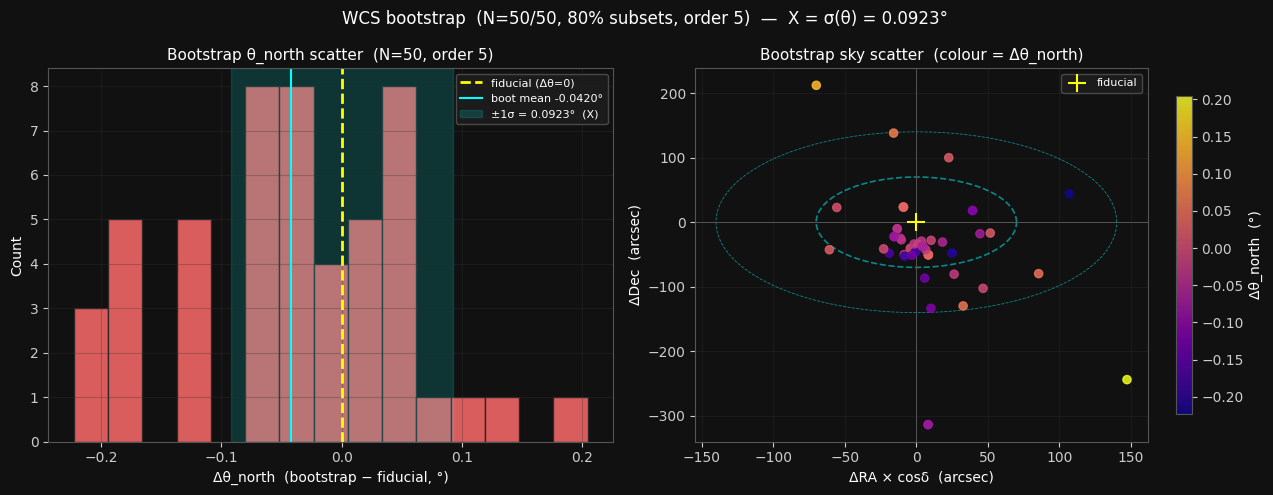

Saved ../out/local_bootstrap_10/bootstrap_histogram.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- left: angle-difference histogram ---
ax = axes[0]
ax.hist(boot_dtheta, bins=min(15, n_ok),
        color='#ff6b6b', edgecolor='#222', alpha=0.85)
ax.axvline(0,                  color='yellow', lw=2,   ls='--', label='fiducial (Δθ=0)')
ax.axvline(boot_dtheta.mean(), color='cyan',   lw=1.5,          label=f'boot mean {boot_dtheta.mean():+.4f}°')
ax.axvspan(-boot_theta_std, boot_theta_std,
           alpha=0.15, color='cyan',
           label=f'±1σ = {boot_theta_std:.4f}°  (X)')
ax.set_xlabel('Δθ_north  (bootstrap − fiducial, °)')
ax.set_ylabel('Count')
ax.set_title(f'Bootstrap θ_north scatter  (N={n_ok}, order {TWEAK_ORDER})')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- right: sky scatter scatter plot ---
ax2 = axes[1]
sc = ax2.scatter(boot_dra_as, boot_ddec_as,
                 c=boot_dtheta, cmap='plasma',
                 s=35, alpha=0.85, zorder=3)
plt.colorbar(sc, ax=ax2, label='Δθ_north  (°)', shrink=0.85)
_t = np.linspace(0, 2*np.pi, 300)
for _r, _lw in [(boot_sep_std, 1.2), (2*boot_sep_std, 0.6)]:
    ax2.plot(_r*np.cos(_t), _r*np.sin(_t), '--', color='cyan', lw=_lw, alpha=0.5)
ax2.axhline(0, color='#555', lw=0.7)
ax2.axvline(0, color='#555', lw=0.7)
ax2.scatter([0], [0], marker='+', color='yellow', s=150, zorder=5, label='fiducial')
ax2.set_xlabel('ΔRA × cosδ  (arcsec)')
ax2.set_ylabel('ΔDec  (arcsec)')
ax2.set_title('Bootstrap sky scatter  (colour = Δθ_north)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle(
    f'WCS bootstrap  (N={n_ok}/{N_BOOT}, {int(BOOT_FRAC*100)}% subsets, '
    f'order {TWEAK_ORDER})  —  X = σ(θ) = {boot_theta_std:.4f}°',
    fontsize=12,
)
fig.tight_layout()
_plot_path = OUT_DIR / 'bootstrap_histogram.png'
fig.savefig(_plot_path, bbox_inches='tight')
plt.show()
print(f"Saved {_plot_path}")

## Cell 8 — Fiducial WCS overlay

Visual sanity check: confirmed WCS grid, detected sources, and matched sources
overlaid on the background-subtracted image.

/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages/astropy/wcs/wcsapi/fitswcs.py:367: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/mnt/c/Users/bassd/Research/Spectra Angle/spectrangle/.venv/lib/python3.11/site-packages

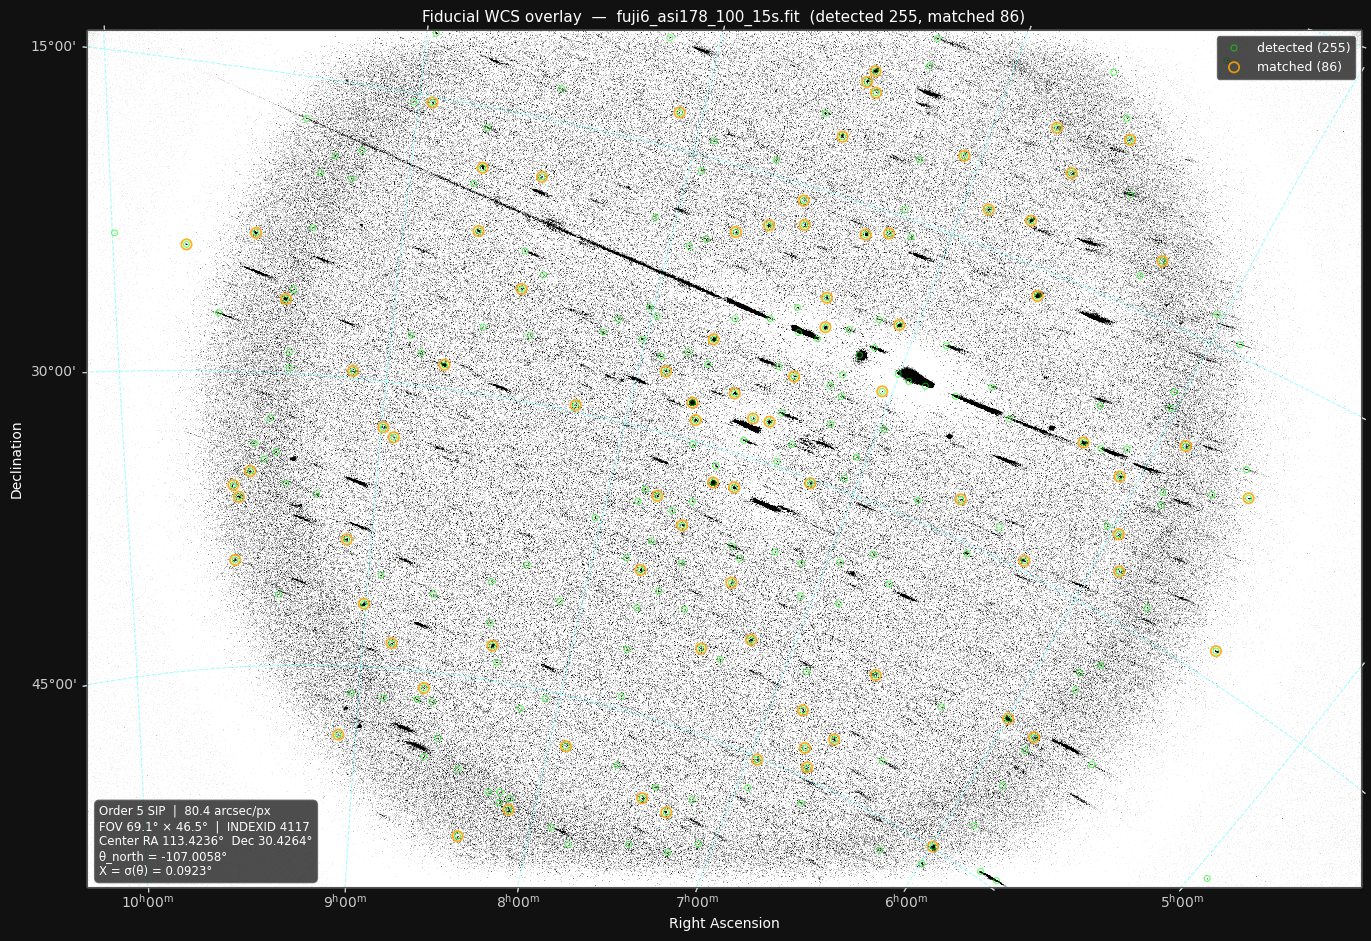

Saved ../out/local_bootstrap_10/fiducial_wcs_overlay.png


In [8]:
from astropy.visualization.wcsaxes import WCSAxes  # noqa: F401  (ensures import)

fig = plt.figure(figsize=(14, 9.5))
ax  = fig.add_subplot(111, projection=fid_wcs)

ax.imshow(disp, origin='lower', cmap='gray_r',
          vmin=_dlo, vmax=_dhi, aspect='equal', interpolation='nearest')

# WCS coordinate grid
ax.coords.grid(True, color='cyan', alpha=0.35, linestyle='--', linewidth=0.8)
ax.coords['ra'].set_major_formatter('hh:mm')
ax.coords['dec'].set_major_formatter('dd:mm')
ax.set_xlabel('Right Ascension', color='white')
ax.set_ylabel('Declination', color='white')

# Detected (submitted) sources
ax.scatter(fid_result.detected_x, fid_result.detected_y,
           transform=ax.get_transform('pixel'),
           s=18, facecolors='none', edgecolors='lime', linewidths=0.8,
           alpha=0.6, label=f'detected ({len(fid_result.detected_x)})')

# Matched (catalog) sources from corr table
if fid_result.corr_table is not None:
    _fx = _col_array(fid_result.corr_table, 'field_x')
    _fy = _col_array(fid_result.corr_table, 'field_y')
    ax.scatter(_fx, _fy,
               transform=ax.get_transform('pixel'),
               s=55, facecolors='none', edgecolors='orange',
               linewidths=1.3, alpha=0.85,
               label=f'matched ({len(_fx)})')

ax.legend(fontsize=9, loc='upper right')

# Stats annotation
_boot_str = (
    f"X = σ(θ) = {boot_theta_std:.4f}°"
    if 'boot_theta_std' in dir() else 'bootstrap not run'
)
_ann = (f"Order {TWEAK_ORDER} SIP  |  {_ps_arcsec:.1f} arcsec/px\n"
        f"FOV {_fov_x_deg:.1f}° × {_fov_y_deg:.1f}°  |  "
        f"INDEXID {_mmeta.get('indexid','?')}\n"
        f"Center RA {fid_metrics.ra_deg:.4f}°  Dec {fid_metrics.dec_deg:.4f}°\n"
        f"θ_north = {fid_metrics.north_angle_deg:.4f}°\n"
        f"{_boot_str}")
ax.text(0.01, 0.01, _ann,
        transform=ax.transAxes,
        fontsize=8.5, color='white',
        verticalalignment='bottom',
        bbox=dict(facecolor='#111', alpha=0.75, edgecolor='#555', boxstyle='round,pad=0.4'))

ax.set_title(
    f'Fiducial WCS overlay  —  {FITS_PATH.name}  '
    f'(detected {len(fid_result.detected_x)}, matched {len(fid_result.matched_x)})',
    fontsize=11,
)

fig.tight_layout()
_overlay_path = OUT_DIR / 'fiducial_wcs_overlay.png'
fig.savefig(_overlay_path, bbox_inches='tight')
plt.show()
print(f"Saved {_overlay_path}")